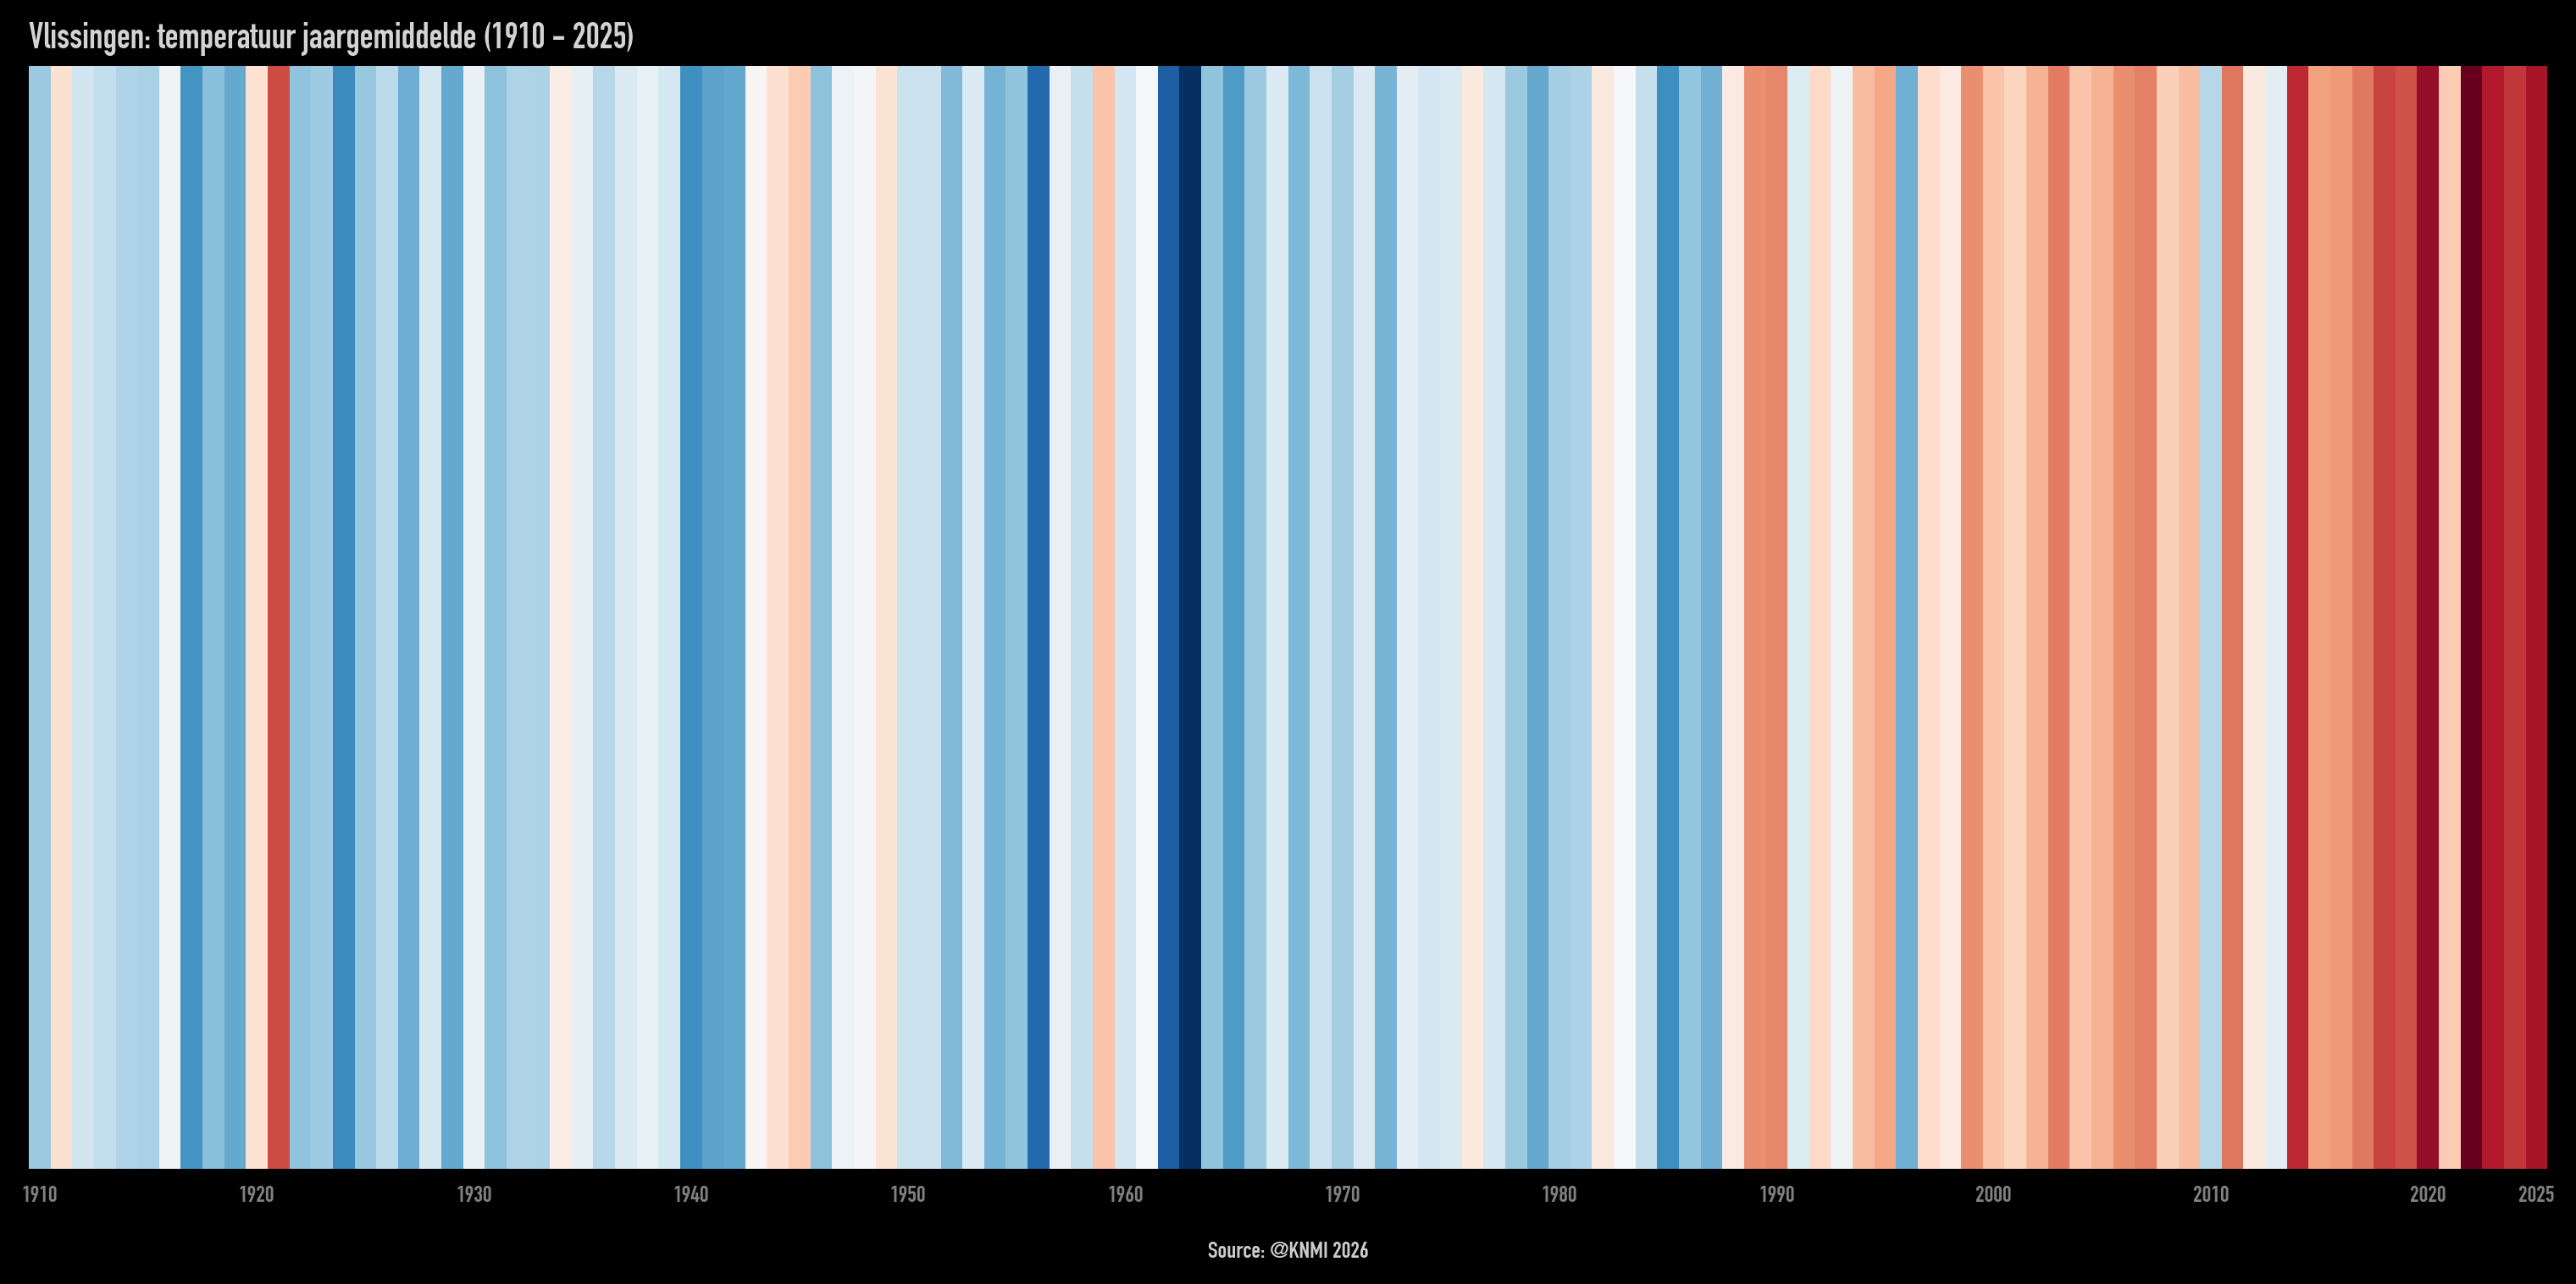

In [257]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

datapad = "etmgeg_310.txt"
df = pd.read_csv(datapad, sep=",",skiprows=50, decimal=",", skipinitialspace=True)
data = df[["YYYYMMDD", "TX"]].copy()
data["YYYYMMDD"] = pd.to_datetime(data["YYYYMMDD"], format="%Y%m%d")
data = data.groupby(data["YYYYMMDD"].dt.year)["TX"].mean().reset_index()
data = data.loc[data["YYYYMMDD"].between(1910, 2025)]
data["TX"] = round(data["TX"]/10, 2)
data

fig, ax = plt.subplots(figsize=(12,6), dpi = 256)

cmap = plt.colormaps["RdBu"].reversed()
norm = plt.Normalize(data["TX"].min(), data["TX"].max())
colors = cmap(norm(data["TX"]))

ax.bar(data["YYYYMMDD"],1 , color=colors, width=1)
ax.set_title("Vlissingen: temperatuur jaargemiddelde (1910 - 2025)", color="lightgray", weight="bold", size=12, loc="left")
ax.spines[["top","right","bottom","left"]].set_visible(False)

ax.set_xticks(np.append(np.arange(1910, 2025, 10), 2025))
ax.xaxis.set_tick_params(pad=2, labelbottom=True, bottom=True, labelsize=8, labelrotation=0, labelcolor="gray")
ax.set_xlim(data["YYYYMMDD"].min()-0.5, data["YYYYMMDD"].max()+0.5)

ax.set_ylabel("", fontsize=10, labelpad=10, color="white")
ax.set_yticks([])
ax.set_ylim(0, 1)

fig.set_facecolor('black')
ax.set_facecolor("Black")

plt.subplots_adjust(bottom=0.08)
ax.text(x=0.5, y=-0.08, s="Source: @KNMI 2026", transform=ax.transAxes, ha='center', fontsize=8, alpha=0.8, color="white")

plt.savefig("vlissingen.png", bbox_inches="tight")
plt.tight_layout()
plt.show()

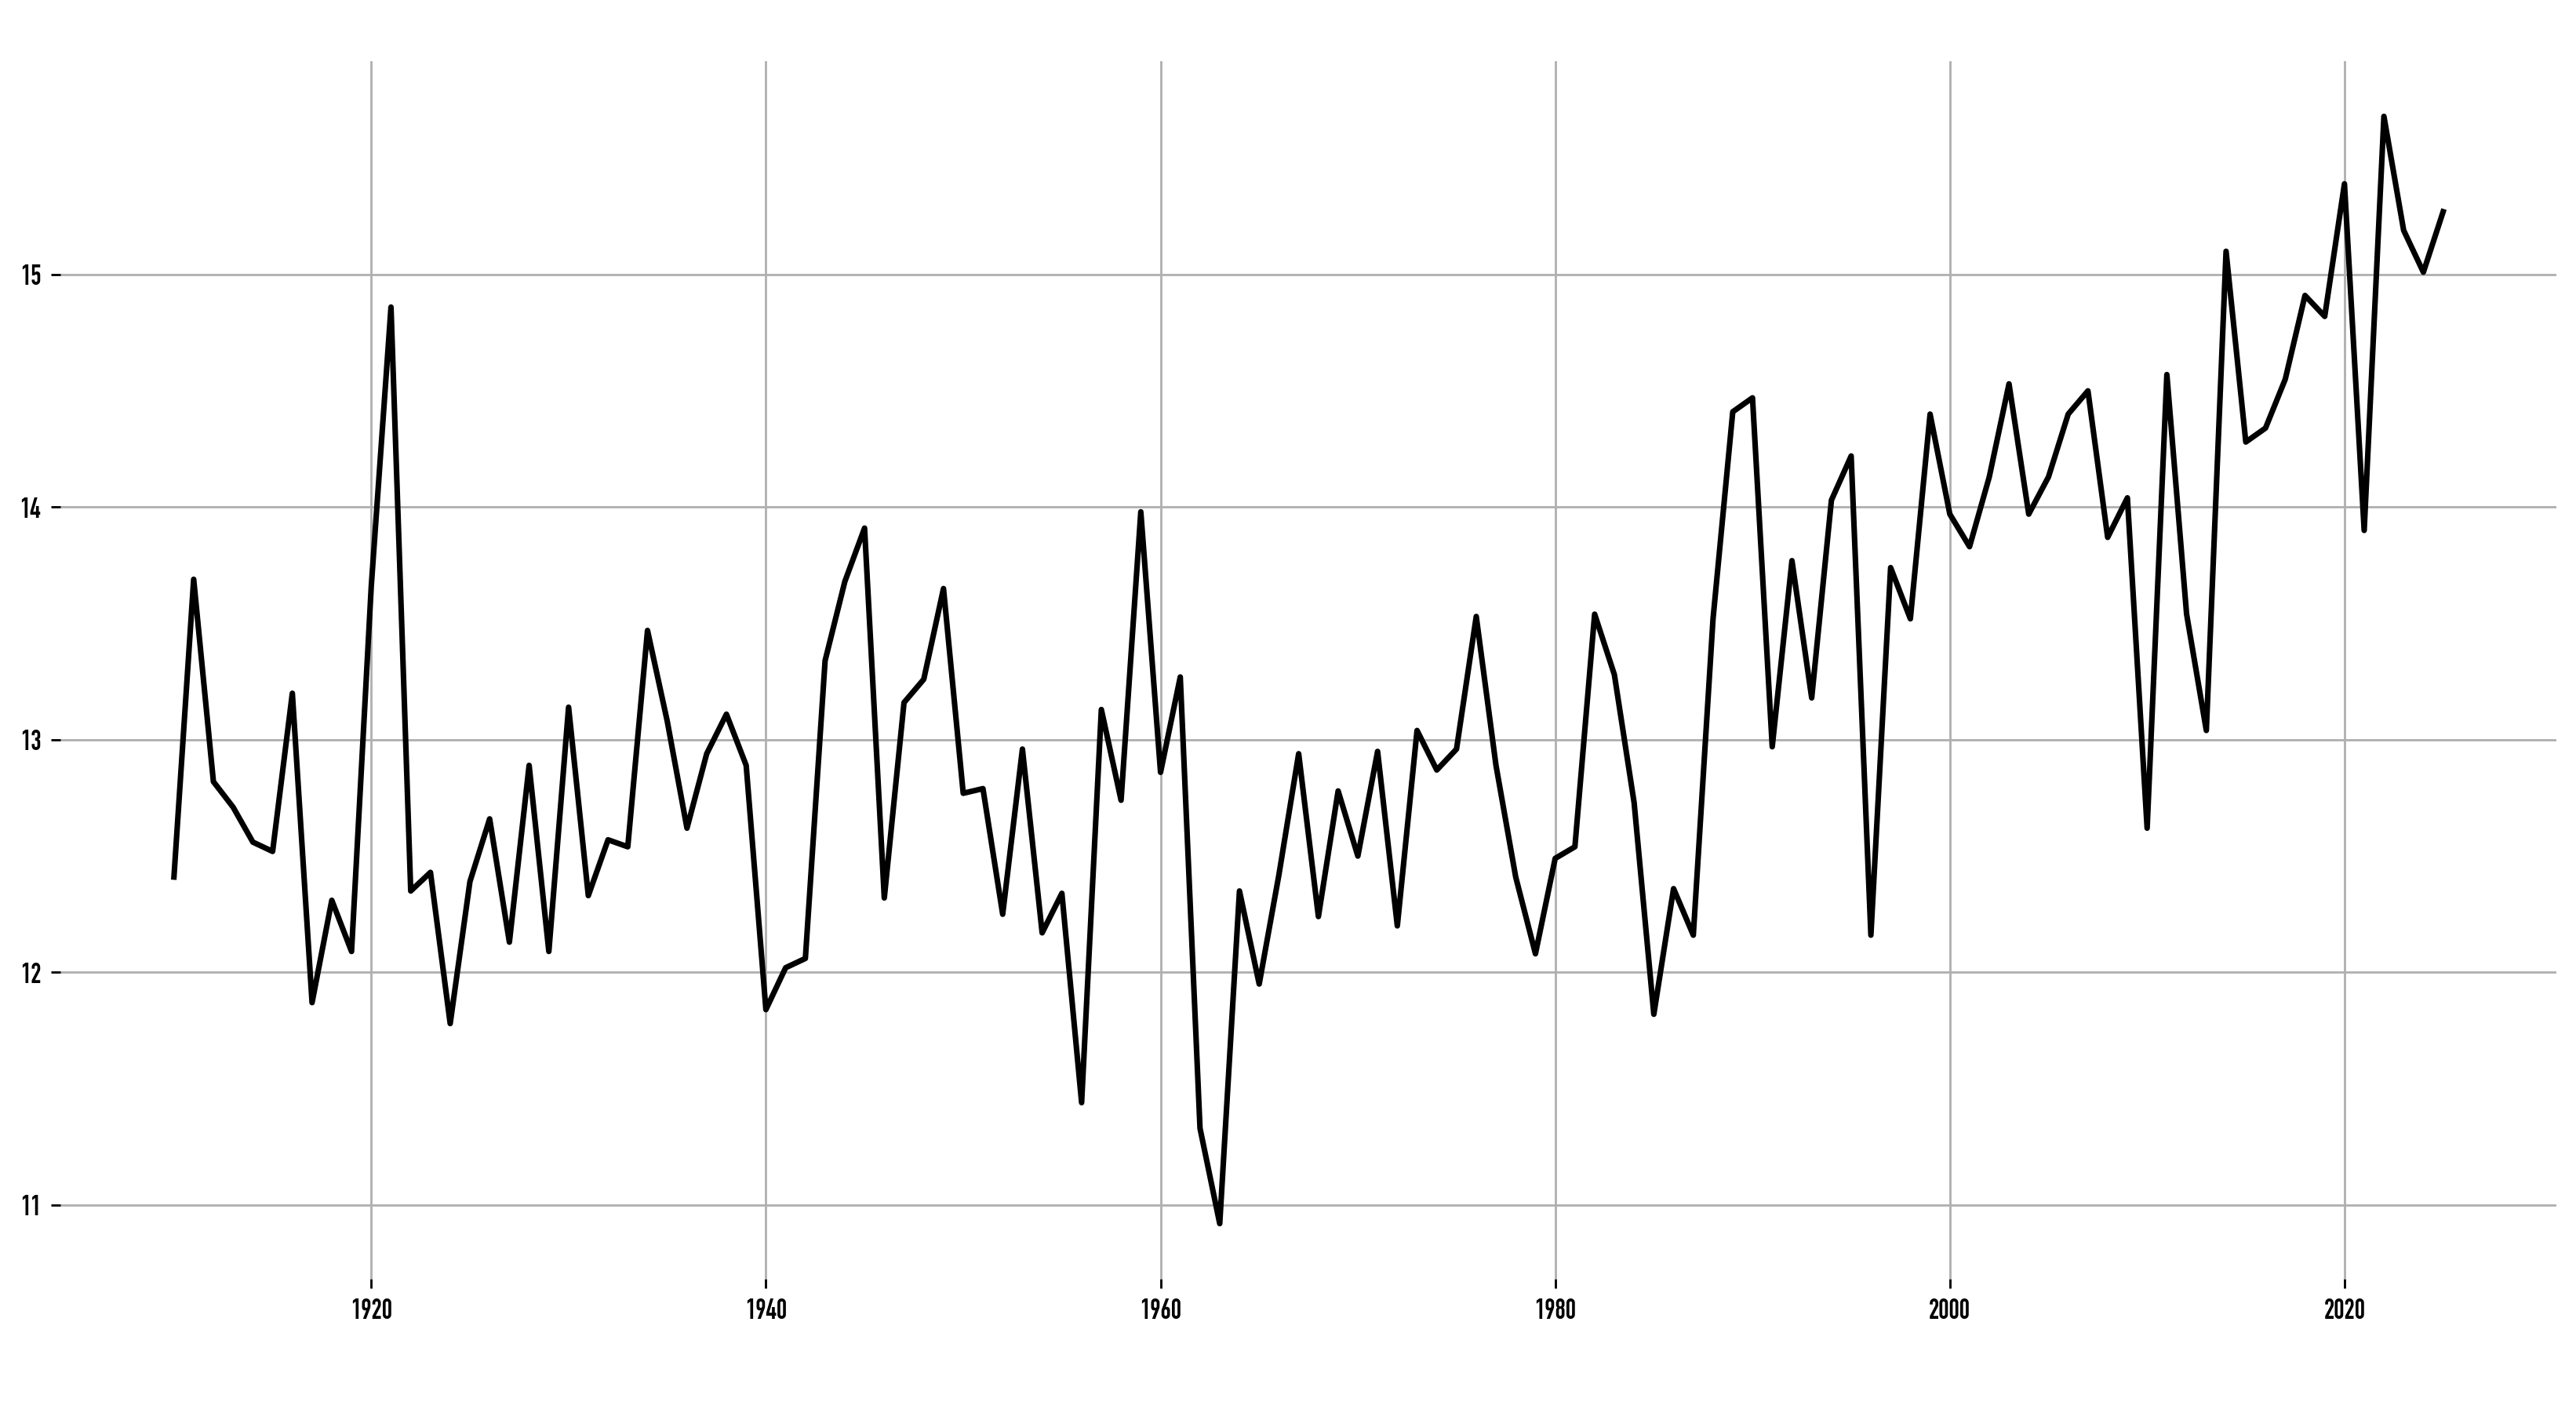

In [218]:
fig, ax = plt.subplots(figsize=(13.33,7.5), dpi = 256)

ax.plot(data["YYYYMMDD"], data["TX"], color="black", linewidth=2)
ax.set_title("Nederland: temperatuur jaargemiddelde (1900 - 2024)", color="white", weight="bold", size=12, loc="left")
ax.spines[["top","right","bottom","left"]].set_visible(False)

ax.grid(axis="both")



plt.subplots_adjust(left=0.1, right=None, top=None, bottom=0.2, wspace=None, hspace=None)
ax.text(x=0.055, y=0.08, s="Source: KNMI - https://www.knmi.nl/over-het-knmi/nieuws/klimaatstreepjescode-warming-stripes", transform=fig.transFigure, ha='left', fontsize=10, alpha=.7, color='white')

plt.tight_layout()
plt.show()

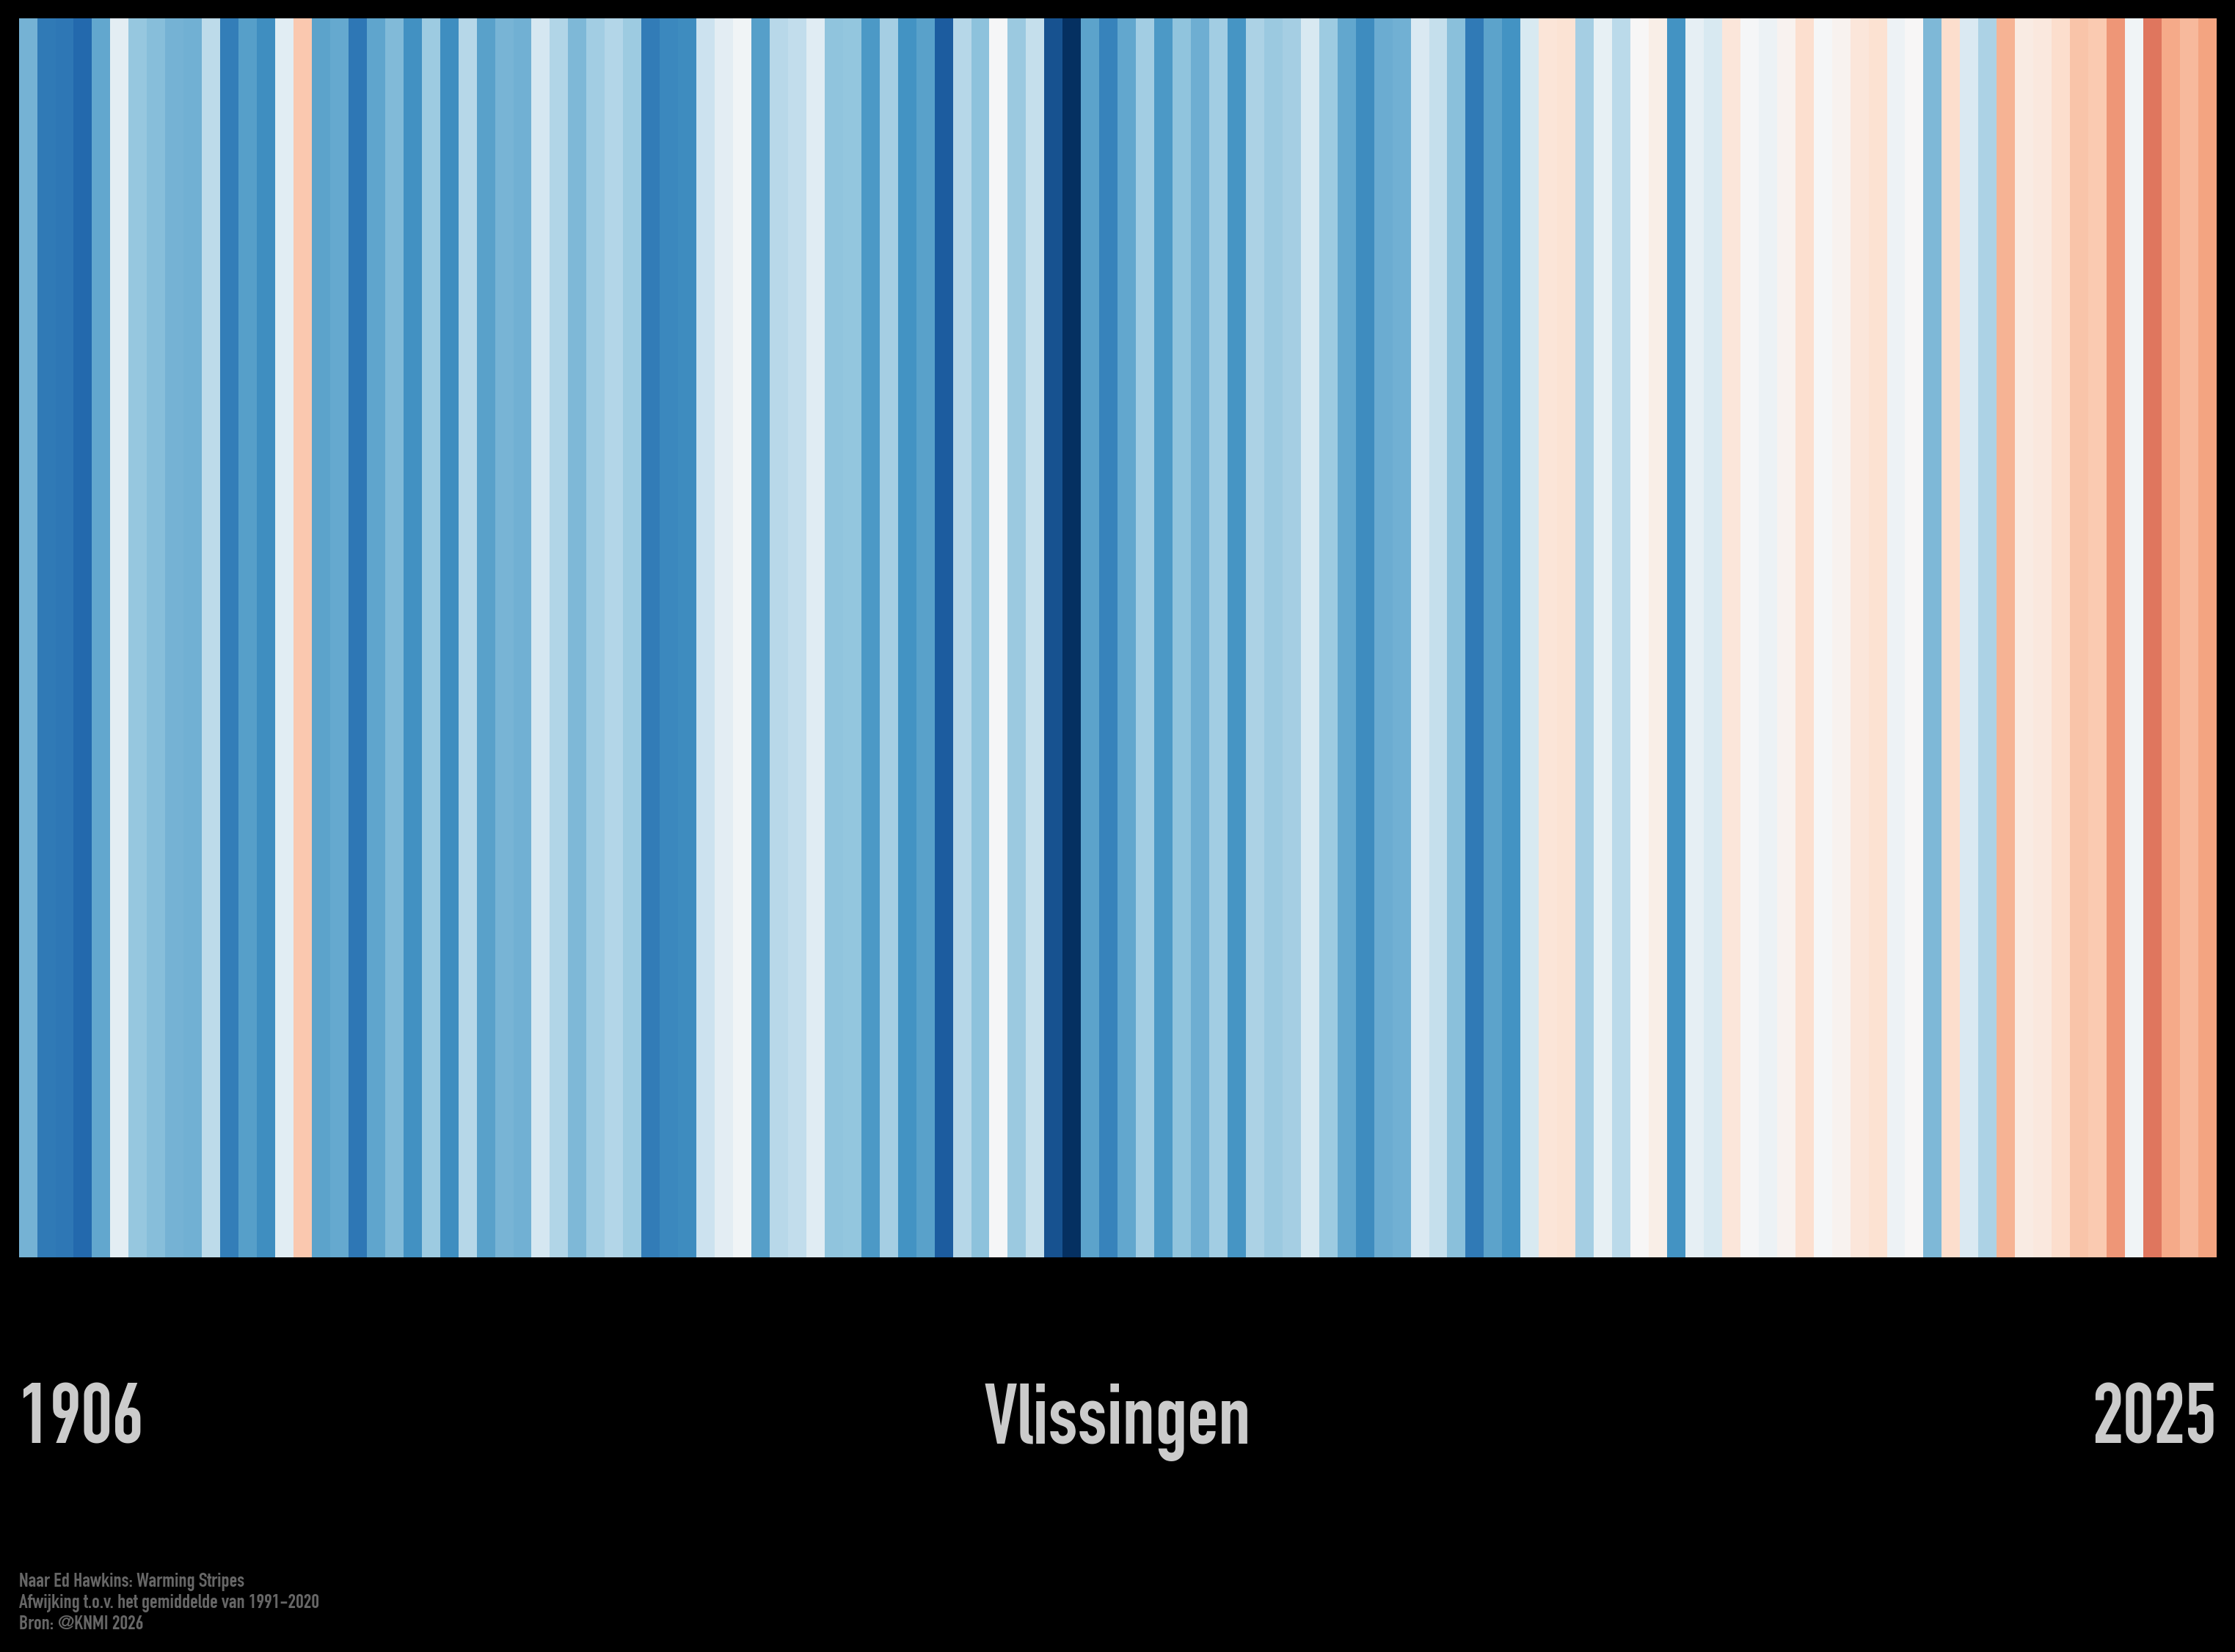

In [258]:
data_2 = df[["YYYYMMDD", "TX"]].copy()
data_2["YYYYMMDD"] = pd.to_datetime(data_2["YYYYMMDD"], format="%Y%m%d")
data_2 = data_2.groupby(data_2["YYYYMMDD"].dt.year)["TX"].mean().reset_index()
data_2 = data_2.loc[data_2["YYYYMMDD"].between(1906, 2025)]
data_2["TX"] = round(data_2["TX"]/10, 2)
data_2

baseline = data_2.loc[data_2["YYYYMMDD"].between(1991, 2020)]["TX"].mean()
data_2["TX_anomaly"] = data_2["TX"] - baseline

fig, ax = plt.subplots(figsize=(12,8), dpi = 256)
plt.rcParams["font.family"] = "DIN Condensed"

cmap = plt.colormaps["RdBu"].reversed()
norm = plt.Normalize(-data_2["TX_anomaly"].abs().max(), data_2["TX_anomaly"].abs().max())
colors = cmap(norm(data_2["TX_anomaly"]))

ax.bar(data_2["YYYYMMDD"],1 , color=colors, width=1)
ax.spines[["top","right","bottom","left"]].set_visible(False)

ax.set_xticks([])
ax.set_xlim(data_2["YYYYMMDD"].min()-0.5, data_2["YYYYMMDD"].max()+0.5)

ax.set_ylabel("", fontsize=10, labelpad=10, color="white")
ax.set_yticks([])
ax.set_ylim(0, 1)

fig.set_facecolor('black')
ax.set_facecolor("Black")

plt.subplots_adjust(top=0.95, bottom=0.5)

ax.text(x=0, y=-0.15, s="1906", transform=ax.transAxes, ha='left', fontsize=32, alpha=0.8, color="white")
ax.text(x=1, y=-0.15, s="2025", transform=ax.transAxes, ha='right', fontsize=32, alpha=0.8, color="white")
ax.text(x=0.5, y=-0.15, s="Vlissingen", transform=ax.transAxes, ha='center', fontsize=32, alpha=0.8, color="white")
ax.text(x=0, y=-0.3, s="Naar Ed Hawkins: Warming Stripes\nAfwijking t.o.v. het gemiddelde van 1991-2020\nBron: @KNMI 2026", transform=ax.transAxes, ha='left', fontsize=8, alpha=0.8, color="grey")

plt.savefig("vlissingen.png", bbox_inches="tight")
plt.tight_layout()
plt.show()